Name: Piriyadharshini N
Roll No: 24BAD086
Best K: 11
Accuracy: 0.9649122807017544
Precision: 0.9534883720930233
Recall: 0.9534883720930233
F1: 0.9534883720930233


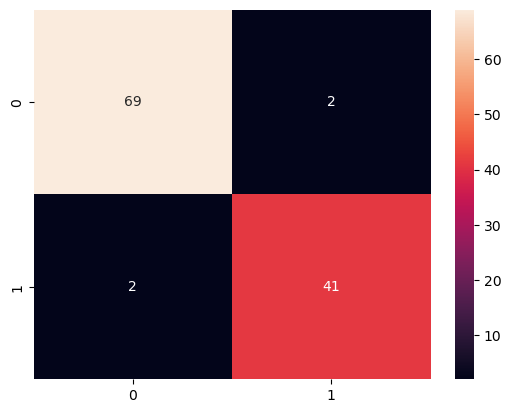

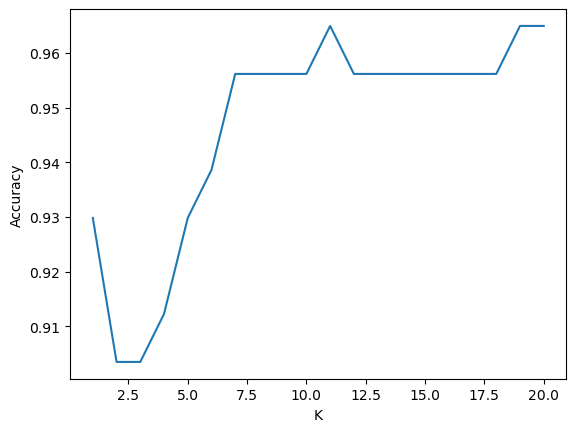

Misclassified Indices: (array([20, 39, 52, 77]),)


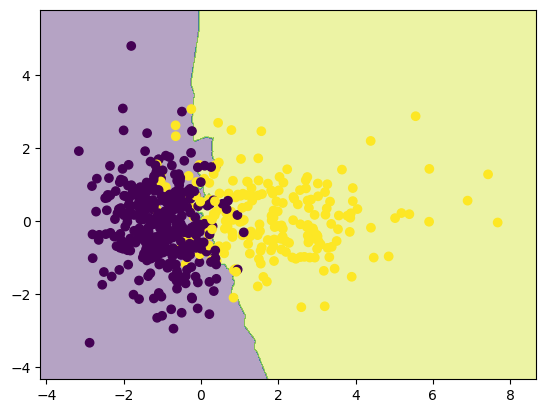

In [1]:
print("Name: Piriyadharshini N\nRoll No: 24BAD086")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA

data = pd.read_csv("breast-cancer.csv")

data = data[['radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean','diagnosis']]

le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])

X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

k_values = range(1,21)
acc_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc_scores.append(accuracy_score(y_test, y_pred))

best_k = k_values[np.argmax(acc_scores)]

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Best K:", best_k)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

plt.plot(k_values, acc_scores)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

misclassified = np.where(y_test != y_pred)
print("Misclassified Indices:", misclassified)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

knn2 = KNeighborsClassifier(n_neighbors=best_k)
knn2.fit(X_train_pca, y_train_pca)

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min,x_max,0.02),
                     np.arange(y_min,y_max,0.02))

Z = knn2.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx,yy,Z,alpha=0.4)
plt.scatter(X_pca[:,0],X_pca[:,1],c=y)
plt.show()

Name: Piriyadharshini N
Roll No: 24BAD086
Shallow Tree Performance
Accuracy: 0.7642276422764228
Precision: 0.7575757575757576
Recall: 0.9375
F1: 0.8379888268156425
Deep Tree Accuracy: 0.7154471544715447


C:\Users\piriyadharshini\AppData\Local\Temp\ipykernel_16636\3183319439.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['LoanAmount'].fillna(data['LoanAmount'].mean(), inplace=True)
C:\Users\piriyadharshini\AppData\Local\Temp\ipykernel_16636\3183319439.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

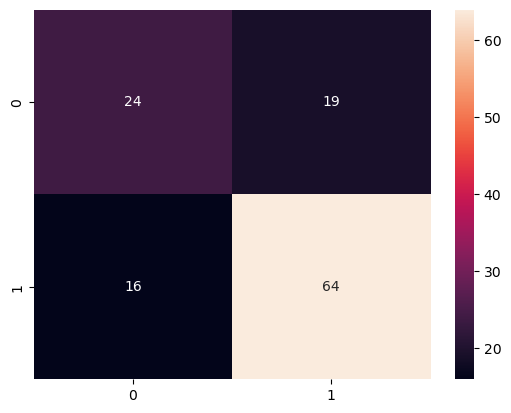

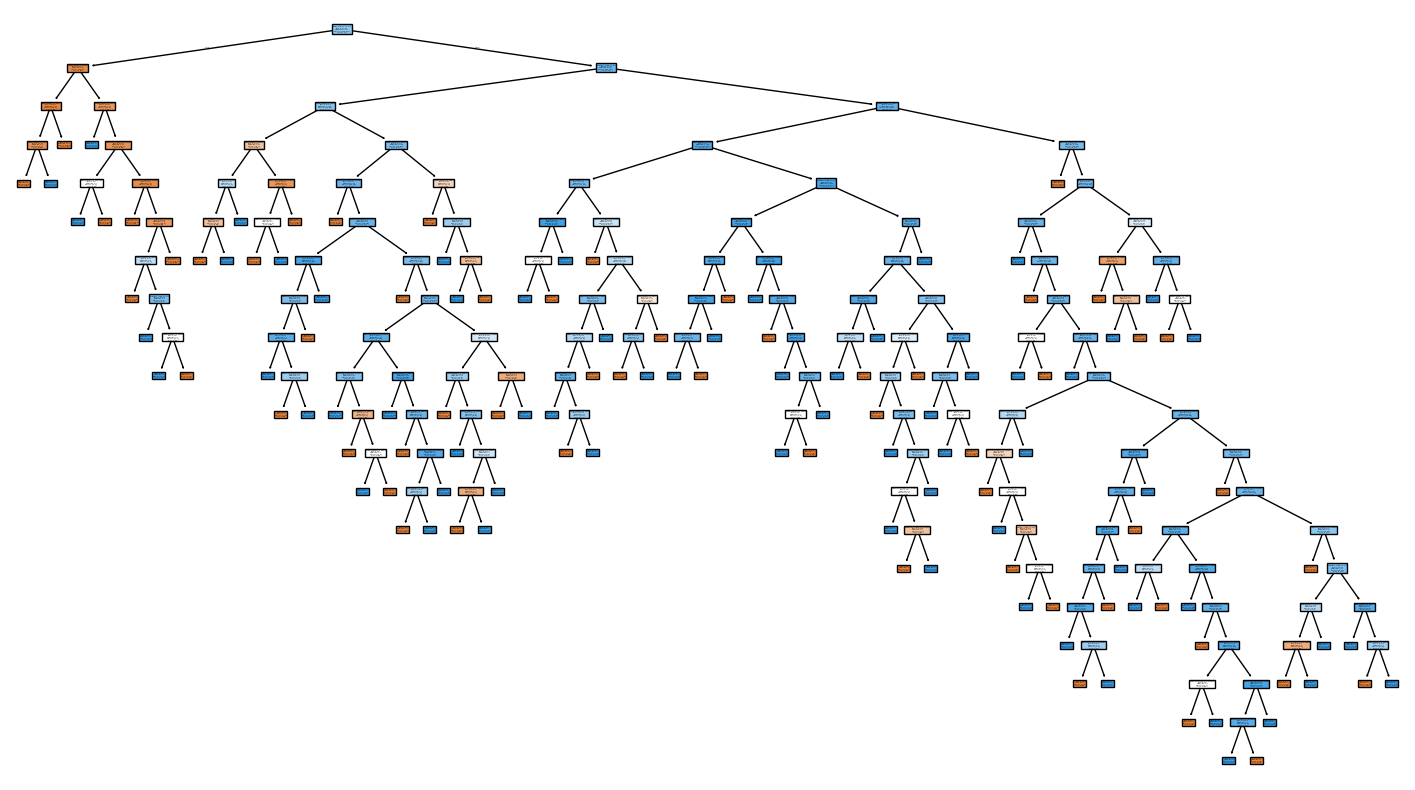

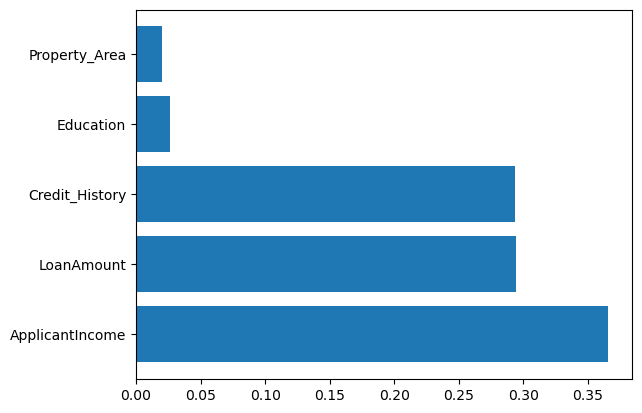

In [3]:
print("Name: Piriyadharshini N\nRoll No: 24BAD086")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

data = pd.read_csv("loan_prediction.csv")

data = data[['ApplicantIncome','LoanAmount','Credit_History','Education','Property_Area','Loan_Status']]

data['LoanAmount'].fillna(data['LoanAmount'].mean(), inplace=True)
data['Credit_History'].fillna(data['Credit_History'].mode()[0], inplace=True)

le = LabelEncoder()

data['Education'] = le.fit_transform(data['Education'])
data['Property_Area'] = le.fit_transform(data['Property_Area'])
data['Loan_Status'] = le.fit_transform(data['Loan_Status'])

X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

dt1 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt1.fit(X_train,y_train)

y_pred1 = dt1.predict(X_test)

acc1 = accuracy_score(y_test,y_pred1)
prec1 = precision_score(y_test,y_pred1)
rec1 = recall_score(y_test,y_pred1)
f11 = f1_score(y_test,y_pred1)

print("Shallow Tree Performance")
print("Accuracy:",acc1)
print("Precision:",prec1)
print("Recall:",rec1)
print("F1:",f11)

dt2 = DecisionTreeClassifier(random_state=42)
dt2.fit(X_train,y_train)

y_pred2 = dt2.predict(X_test)

acc2 = accuracy_score(y_test,y_pred2)

print("Deep Tree Accuracy:",acc2)

cm = confusion_matrix(y_test,y_pred2)

sns.heatmap(cm,annot=True,fmt='d')
plt.show()

plt.figure(figsize=(18,10))
plot_tree(dt2,feature_names=X.columns,class_names=['No','Yes'],filled=True)
plt.show()

importances = dt2.feature_importances_

plt.barh(X.columns,importances)
plt.show()